In [1]:
import gcinfo
import pandas as pd
import matplotlib.pyplot as plt

gcinfo.search_titles(query="non-permanent", format_filter="CSV")

Canadian Cannabis Survey (CCS) 2023 Public Use Microdata File (PUMF)
Federal Corporations
Lidar - Digital models (terrain, canopy, slope, level curve)
Trucking network
Potential flow bed from LiDAR
Vegetation in Northern Quebec
Water levels during a flood (since 2017)
Traffic flow
Syndicate or office of forest producers
Administrative divisions
Civil security events
Biological refuge (designated and planned)
River drainage areas and lake catchments
Regional agency for the development of private forests
Primary wood processing plants
Health inspections from the Real Estate and Housing Strategy Department
Portrait of forest cover in Quebec
Geotechnical investigation site
Located on the street: The neighborhoods of Montreal
Business Development Corporation (SDC) limit


In [2]:
gcinfo.list_resources(gcinfo.search_datasets(query='title:"Estimates of the number of non-permanent residents by type, quarterly"')["results"][0])


=== Estimates of the number of non-permanent residents by type, quarterly ===
ID: f8f711fa-6b75-4178-a60c-23093c071fc8
Org: Statistics Canada | Statistique Canada
Notes: This table provides quarterly estimates of the number of non-permanent residents by type for Canada, provinces and territories.<br>...
URL: https://www150.statcan.gc.ca/t1/tbl1/en/tv.action?pid=1710012101
Citation: Statistics Canada. Table 17-10-0121-01 Estimates of the number of non-permanent residents by type, quarterly
DOI:      https://doi.org/10.25318/1710012101-eng
  [CSV     ] Dataset
           https://www150.statcan.gc.ca/n1/tbl/csv/17100121-fra.zip
  [CSV     ] Dataset
           https://www150.statcan.gc.ca/n1/tbl/csv/17100121-eng.zip
  [XML     ] Dataset
           https://www150.statcan.gc.ca/n1/tbl/sdmx/17100121-SDMX.zip


In [3]:
df_non_permanent, df_non_permanent_meta = gcinfo.download_zip("https://www150.statcan.gc.ca/n1/tbl/csv/17100121-eng.zip")

Using cached file: cache\17100121-eng.zip


In [4]:
gcinfo.search_titles(query="quarterly demographic estimates", format_filter="CSV")

Public Service Commission's Staffing Dashboard
Estimates of the components of natural increase, quarterly
Estimates of interprovincial migrants by province or territory of origin and destination, quarterly
Estimates of the components of international migration, quarterly
Estimates of the components of interprovincial migration, quarterly
Population estimates, quarterly
Estimates of the components of demographic growth, annual
Precocity errors for components of demographic growth, annual
Estimates of the number of non-permanent residents by type, quarterly
Household sector credit market summary table, seasonally adjusted estimates
Asking rent and paid rent prices, by rental unit type and number of bedrooms, experimental estimates
International trade in services, monthly
General governments final consumption expenditure, Canada, quarterly
Residential housing development by access to public transport areas, geography, construction status, dwelling and market type, quarterly, inactive
Resi

In [5]:
gcinfo.list_resources(gcinfo.search_datasets(query='title:"Population estimates, quarterly"')["results"][0])


=== Population estimates, quarterly ===
ID: ec690886-687d-4d59-9b1b-51311435d344
Org: Statistics Canada | Statistique Canada
Notes: Estimated number of persons by quarter of a year and by year, Canada, provinces and territories....
URL: https://www150.statcan.gc.ca/t1/tbl1/en/tv.action?pid=1710000901
Citation: Statistics Canada. Table 17-10-0009-01 Population estimates, quarterly
DOI:      https://doi.org/10.25318/1710000901-eng
  [CSV     ] Dataset
           https://www150.statcan.gc.ca/n1/tbl/csv/17100009-fra.zip
  [CSV     ] Dataset
           https://www150.statcan.gc.ca/n1/tbl/csv/17100009-eng.zip
  [XML     ] Dataset
           https://www150.statcan.gc.ca/n1/tbl/sdmx/17100009-SDMX.zip


In [6]:
df_population, df_population_meta = gcinfo.download_zip("https://www150.statcan.gc.ca/n1/tbl/csv/17100009-eng.zip")

Using cached file: cache\17100009-eng.zip


In [7]:
df_population.head()

,REF_DATE,GEO,DGUID,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,1946-01-01,Canada,2021A000011124,Persons,249,units,0,v1,1,12188000,NaN,NaN,NaN,0
1,1946-04-01,Canada,2021A000011124,Persons,249,units,0,v1,1,12241000,NaN,NaN,NaN,0
2,1946-07-01,Canada,2021A000011124,Persons,249,units,0,v1,1,12316000,NaN,NaN,NaN,0
3,1946-10-01,Canada,2021A000011124,Persons,249,units,0,v1,1,12393000,NaN,NaN,NaN,0
4,1947-01-01,Canada,2021A000011124,Persons,249,units,0,v1,1,12450000,NaN,NaN,NaN,0


In [20]:
df_canada_population = df_population[df_population["GEO"].str.contains("Canada")][["GEO", "REF_DATE", "VALUE"]]
df_canada_population.tail(10)

,GEO,REF_DATE,VALUE
3937,Canada,2024-04-01,40912561
3951,Canada,2024-07-01,41162593
3965,Canada,2024-10-01,41373096
3979,Canada,2025-01-01,41435888
3993,Canada,2025-04-01,41495432
4007,Canada,2025-07-01,41608982
4021,Canada,2025-10-01,41723923
4035,Canada,2026-01-01,41716698
4049,Canada,2026-04-01,41718064
4063,Canada,2026-07-01,41798407


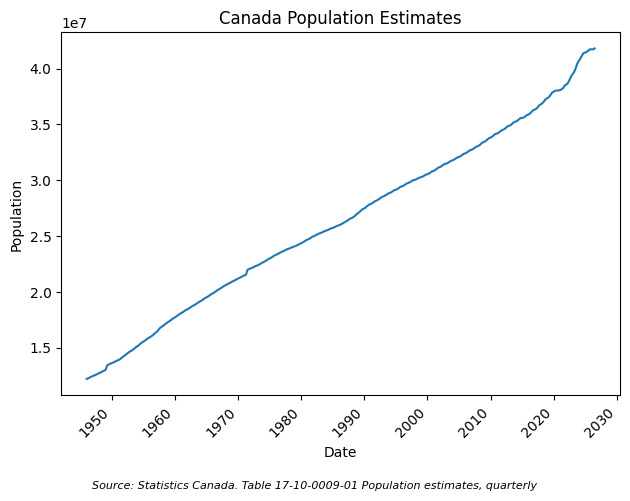

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

df_canada_population["REF_DATE"] = pd.to_datetime(df_canada_population["REF_DATE"])

ax.plot(
    df_canada_population["REF_DATE"],
    df_canada_population["VALUE"],
    linestyle="-"
)

ax.set_title("Canada Population Estimates")
ax.set_xlabel("Date")
ax.set_ylabel("Population")

plt.xticks(rotation=45, ha="right")
plt.subplots_adjust(bottom=0.3)

plt.figtext(
    0.5, -0.03,
    "Source: Statistics Canada. Table 17-10-0009-01 Population estimates, quarterly",
    ha="center",
    fontsize=8,
    style="italic"
)

plt.tight_layout()
plt.show()

In [10]:
df_canada_population.iloc[-1]

GEO                      Canada
REF_DATE    2026-07-01 00:00:00
VALUE                  41798407
Name: 4063, dtype: object

In [11]:
df_non_permanent.head()

,REF_DATE,GEO,DGUID,Non-permanent resident types,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,2021-07-01,Canada,2021A000011124,"Total, non-permanent residents",Persons,249,units,0,v1566927590,1.1,1326000,NaN,NaN,NaN,0
1,2021-07-01,Canada,2021A000011124,"Total, asylum claimants, protected persons and...",Persons,249,units,0,v1566927591,1.2,168239,NaN,NaN,NaN,0
2,2021-07-01,Canada,2021A000011124,"Asylum claimants, protected persons and relate...",Persons,249,units,0,v1566927592,1.3,94262,NaN,NaN,NaN,0
3,2021-07-01,Canada,2021A000011124,"Asylum claimants, protected persons and relate...",Persons,249,units,0,v1566927593,1.4,1490,NaN,NaN,NaN,0
4,2021-07-01,Canada,2021A000011124,"Asylum claimants, protected persons and relate...",Persons,249,units,0,v1566927594,1.5,4091,NaN,NaN,NaN,0


In [12]:
df_canada_non_permanent = df_non_permanent[df_non_permanent["GEO"].str.contains("Canada")]
df_canada_non_permanent.head()

,REF_DATE,GEO,DGUID,Non-permanent resident types,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,2021-07-01,Canada,2021A000011124,"Total, non-permanent residents",Persons,249,units,0,v1566927590,1.1,1326000,NaN,NaN,NaN,0
1,2021-07-01,Canada,2021A000011124,"Total, asylum claimants, protected persons and...",Persons,249,units,0,v1566927591,1.2,168239,NaN,NaN,NaN,0
2,2021-07-01,Canada,2021A000011124,"Asylum claimants, protected persons and relate...",Persons,249,units,0,v1566927592,1.3,94262,NaN,NaN,NaN,0
3,2021-07-01,Canada,2021A000011124,"Asylum claimants, protected persons and relate...",Persons,249,units,0,v1566927593,1.4,1490,NaN,NaN,NaN,0
4,2021-07-01,Canada,2021A000011124,"Asylum claimants, protected persons and relate...",Persons,249,units,0,v1566927594,1.5,4091,NaN,NaN,NaN,0


In [13]:
df_canada_non_permanent["REF_DATE"] = pd.to_datetime(df_canada_non_permanent["REF_DATE"])

C:\Users\D\AppData\Local\Temp\ipykernel_21112\691056638.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_canada_non_permanent["REF_DATE"] = pd.to_datetime(df_canada_non_permanent["REF_DATE"])


In [14]:
df_canada_non_permanent_total = df_canada_non_permanent[df_canada_non_permanent["Non-permanent resident types"] == "Total, non-permanent residents"]
df_canada_non_permanent_total.head()

,REF_DATE,GEO,DGUID,Non-permanent resident types,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,2021-07-01,Canada,2021A000011124,"Total, non-permanent residents",Persons,249,units,0,v1566927590,1.1,1326000,NaN,NaN,NaN,0
154,2021-10-01,Canada,2021A000011124,"Total, non-permanent residents",Persons,249,units,0,v1566927590,1.1,1408873,NaN,NaN,NaN,0
308,2022-01-01,Canada,2021A000011124,"Total, non-permanent residents",Persons,249,units,0,v1566927590,1.1,1372025,NaN,NaN,NaN,0
462,2022-04-01,Canada,2021A000011124,"Total, non-permanent residents",Persons,249,units,0,v1566927590,1.1,1397019,NaN,NaN,NaN,0
616,2022-07-01,Canada,2021A000011124,"Total, non-permanent residents",Persons,249,units,0,v1566927590,1.1,1546638,NaN,NaN,NaN,0


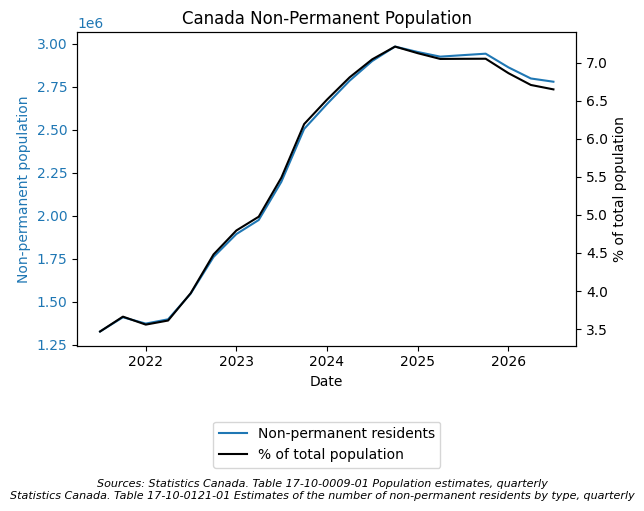

In [15]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax1 = plt.subplots()

# Left axis – absolute non-permanent population
ax1.plot(
    df_canada_non_permanent_total["REF_DATE"],
    df_canada_non_permanent_total["VALUE"],
    color="tab:blue",
    linestyle="-",
    label="Non-permanent residents"
)
ax1.set_xlabel("Date")
ax1.set_ylabel("Non-permanent population", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# Right axis – percentage of total population
pop_lookup = dict(zip(df_canada_population["REF_DATE"], df_canada_population["VALUE"]))

pct = [
    val / pop_lookup[date] * 100
    if date in pop_lookup else np.nan
    for date, val in zip(
        df_canada_non_permanent_total["REF_DATE"],
        df_canada_non_permanent_total["VALUE"]
    )
]

ax2 = ax1.twinx()
ax2.plot(
    df_canada_non_permanent_total["REF_DATE"],
    pct,
    color="black",
    linestyle="-",
    label="% of total population"
)
ax2.set_ylabel("% of total population", color="black")
ax2.tick_params(axis="y", labelcolor="black")

ax1.set_title("Canada Non-Permanent Population")

# Combined legend below the plot
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    title=None,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=1,
    frameon=True
)

plt.xticks(rotation=45, ha="right")
plt.subplots_adjust(bottom=0.3)

plt.figtext(
    0.5, -0.05,
    "Sources: Statistics Canada. Table 17-10-0009-01 Population estimates, quarterly\nStatistics Canada. Table 17-10-0121-01 Estimates of the number of non-permanent residents by type, quarterly",
    ha="center",
    fontsize=8,
    style="italic"
)

plt.tight_layout()
plt.show()

In [16]:
most_recent_canada_total_non_permanent = df_canada_non_permanent_total.iloc[-1]
most_recent_canada_total_non_permanent

REF_DATE                                   2026-07-01 00:00:00
GEO                                                     Canada
DGUID                                           2021A000011124
Non-permanent resident types    Total, non-permanent residents
UOM                                                    Persons
UOM_ID                                                     249
SCALAR_FACTOR                                            units
SCALAR_ID                                                    0
VECTOR                                             v1566927590
COORDINATE                                                 1.1
VALUE                                                  2779774
STATUS                                                     NaN
SYMBOL                                                     NaN
TERMINATED                                                 NaN
DECIMALS                                                     0
Name: 3080, dtype: object

In [17]:
most_recent_canada_total_population = df_canada_population.iloc[-1]
most_recent_canada_total_population

GEO                      Canada
REF_DATE    2026-07-01 00:00:00
VALUE                  41798407
Name: 4063, dtype: object

In [18]:
import numpy as np

np.round(most_recent_canada_total_non_permanent.VALUE / most_recent_canada_total_population.VALUE * 100, 2)

np.float64(6.65)

In [19]:
df_non_permanent[df_non_permanent["REF_DATE"] == "2026-04-01"]

,REF_DATE,GEO,DGUID,Non-permanent resident types,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
2926,2026-04-01,Canada,2021A000011124,"Total, non-permanent residents",Persons,249,units,0,v1566927590,1.10,2798649,NaN,NaN,NaN,0
2927,2026-04-01,Canada,2021A000011124,"Total, asylum claimants, protected persons and...",Persons,249,units,0,v1566927591,1.20,537105,NaN,NaN,NaN,0
2928,2026-04-01,Canada,2021A000011124,"Asylum claimants, protected persons and relate...",Persons,249,units,0,v1566927592,1.30,373969,NaN,NaN,NaN,0
2929,2026-04-01,Canada,2021A000011124,"Asylum claimants, protected persons and relate...",Persons,249,units,0,v1566927593,1.40,2456,NaN,NaN,NaN,0
2930,2026-04-01,Canada,2021A000011124,"Asylum claimants, protected persons and relate...",Persons,249,units,0,v1566927594,1.50,24439,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3075,2026-04-01,Nunavut,2021A000262,"Total, permit holders and their family members",Persons,249,units,0,v1566927739,14.70,212,NaN,NaN,NaN,0
3076,2026-04-01,Nunavut,2021A000262,Work permit holders only,Persons,249,units,0,v1566927740,14.80,176,NaN,NaN,NaN,0
3077,2026-04-01,Nunavut,2021A000262,Study permit holders only,Persons,249,units,0,v1566927741,14.90,11,NaN,NaN,NaN,0
3078,2026-04-01,Nunavut,2021A000262,Work and study permit holders,Persons,249,units,0,v1566927742,14.10,5,NaN,NaN,NaN,0
